In [1]:
# 1. Import Libraries
import os
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image, UnidentifiedImageError
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import load_model

In [7]:
# 🔥 Important: Now point to the 'train' folder specifically
data_path = "C:/Users/vanka/Downloads/scr/Oily-Dry-Skin-Types/train"

# Get categories (dry, normal, oily)
categories = [folder for folder in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, folder))]
print(f"Detected categories: {categories}")

X = []
y = []

# Loop over each category
for category in categories:
    folder = os.path.join(data_path, category)
    label = category
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        
        if os.path.isfile(img_path):
            try:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (224, 224))
                img = img / 255.0  # Normalize
                
                X.append(img)
                y.append(label)
            except (UnidentifiedImageError, Exception) as e:
                print(f"Error loading image: {img_path} -> {e}")
                continue

X = np.array(X)
y = np.array(y)

print(f"✅ Loaded {len(X)} images successfully.")


Detected categories: ['dry', 'normal', 'oily']
✅ Loaded 2756 images successfully.


In [8]:
# 4. Encode Labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [9]:
# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [10]:
# 6. Build the Model (Transfer Learning using VGG16)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False  # Freeze VGG16 layers

# Add custom layers
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(len(categories), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [11]:
# 7. Train the Model
history = model.fit(X_train, y_train, epochs=8, validation_data=(X_test, y_test))

Epoch 1/8
69/69 ━━━━━━━━━━━━━━━━━━━━ 355s 5s/step - accuracy: 0.4001 - loss: 2.4342 - val_accuracy: 0.6051 - val_loss: 0.8342
Epoch 2/8
69/69 ━━━━━━━━━━━━━━━━━━━━ 347s 5s/step - accuracy: 0.7668 - loss: 0.6210 - val_accuracy: 0.6775 - val_loss: 0.7542
Epoch 3/8
69/69 ━━━━━━━━━━━━━━━━━━━━ 350s 5s/step - accuracy: 0.8670 - loss: 0.3973 - val_accuracy: 0.7192 - val_loss: 0.6824
Epoch 4/8
69/69 ━━━━━━━━━━━━━━━━━━━━ 364s 5s/step - accuracy: 0.9467 - loss: 0.2554 - val_accuracy: 0.7971 - val_loss: 0.5015
Epoch 5/8
69/69 ━━━━━━━━━━━━━━━━━━━━ 343s 5s/step - accuracy: 0.9830 - loss: 0.1464 - val_accuracy: 0.7699 - val_loss: 0.6015
Epoch 6/8
69/69 ━━━━━━━━━━━━━━━━━━━━ 338s 5s/step - accuracy: 0.9756 - loss: 0.1296 - val_accuracy: 0.8261 - val_loss: 0.4536
Epoch 7/8
69/69 ━━━━━━━━━━━━━━━━━━━━ 318s 5s/step - accuracy: 0.9939 - loss: 0.0797 - val_accuracy: 0.8370 - val_loss: 0.4435
Epoch 8/8
69/69 ━━━━━━━━━━━━━━━━━━━━ 313s 5s/step - accuracy: 0.9984 - loss: 0.0523 - val_accuracy: 0.8424 - val_loss:

In [12]:
# 8. Evaluate the Model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

18/18 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.8399 - loss: 0.4239
Test Accuracy: 84.24%


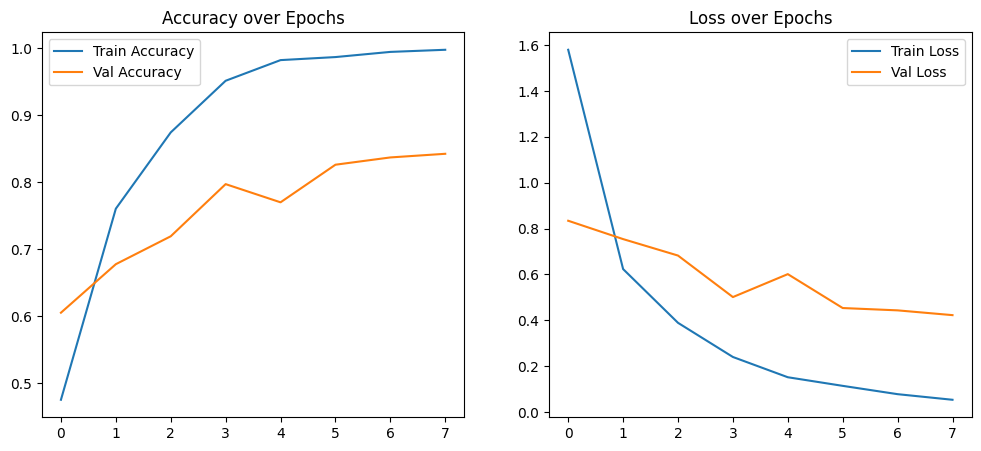

In [13]:
# 9. Plot Accuracy and Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss over Epochs')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step


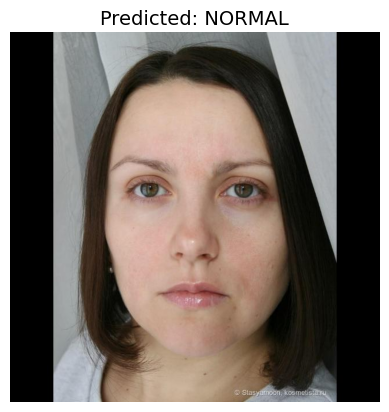

✅ Predicted Skin Type: normal

🎯 Recommended Products for NORMAL Skin:

🧴 Product: AIZEN Incredipeel Exfoliating + Purifying Facial Toner
🏷️ Brand: AIZEN 
🔬 Notable Effects: Balancing, Oil-Control, Pore-Care
💰 Price: Rp 139.000
🔗 Link: https://www.beautyhaul.com/product/detail/incredipeel-exfoliating-purifying-facial-toner
--------------------------------------------------
🧴 Product: Wardah UV Shield Essential Sunscreen Gel SPF 30 PA+++
🏷️ Brand: WARDAH
🔬 Notable Effects: Brightening, UV-Protection
💰 Price: Rp 35.500
🔗 Link: https://www.wardahbeauty.com/en/product/skincare/wardah-uv-shield-essential-sunscreen-gel-spf-30-pa?ref=https://www.wardahbeauty.com/en/product/list/skincare/sort/uv-shield-series?page=1
--------------------------------------------------
🧴 Product: COSRX Hyaluronic Acid Intensive Cream 
🏷️ Brand: COSRX
🔬 Notable Effects: Hydrating, Moisturizing
💰 Price: Rp 270.000
🔗 Link: https://www.sociolla.com/face-cream-lotion/9594-hyaluronic-acid-intensive-cream
--------------

In [14]:
# Load the trained skin type classification model
model = load_model("pv.keras")

# Skin type class labels (must match training order)
class_names = ['dry', 'normal', 'oily']

# Load skincare product dataset
product_data = pd.read_csv("export_skincare.csv")
product_data.columns = product_data.columns.str.strip()  # Clean column names

# Function to recommend products based on predicted skin type
def recommend_products(skin_type, num_recommendations=5):
    skin_type = skin_type.lower().strip()

    # Use binary column (e.g., 'Normal', 'Dry', 'Oily') for filtering
    column_map = {
        'dry': 'Dry',
        'normal': 'Normal',
        'oily': 'Oily'
    }

    column_name = column_map.get(skin_type)
    if not column_name or column_name not in product_data.columns:
        print(f"❌ Skin type '{skin_type}' is not supported.")
        return

    matched_products = product_data[product_data[column_name] == 1]

    if matched_products.empty:
        print(f"⚠️ No products found for {skin_type} skin.")
        return

    print(f"\n🎯 Recommended Products for {skin_type.upper()} Skin:\n")
    top_products = matched_products.sample(n=min(num_recommendations, len(matched_products)), random_state=42)

    for _, row in top_products.iterrows():
        print(f"🧴 Product: {row['product_name']}")
        print(f"🏷️ Brand: {row['brand']}")
        print(f"🔬 Notable Effects: {row.get('notable_effects', 'N/A')}")
        print(f"💰 Price: {row.get('price', 'N/A')}")
        print(f"🔗 Link: {row.get('product_href', 'No link available')}")
        print("-" * 50)

# Function to predict skin type from an image and recommend products
def predict_skin_type(img_path):
    try:
        # Preprocess image
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = preprocess_input(img_array)
        img_array = np.expand_dims(img_array, axis=0)

        # Predict skin type
        prediction = model.predict(img_array)
        pred_class = np.argmax(prediction)
        predicted_skin_type = class_names[pred_class]

        # Show the image and predicted result
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"Predicted: {predicted_skin_type.upper()}", fontsize=14)
        plt.show()

        print(f"✅ Predicted Skin Type: {predicted_skin_type}")
        recommend_products(predicted_skin_type)

    except Exception as e:
        print(f"❌ Error predicting image: {e}")

# Example usage
predict_skin_type("4.jpg")  # Replace with your image path


In [15]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array, load_img

# Load your trained model
model = tf.keras.models.load_model('pv.keras')

# Define class labels (according to your training)
class_names = ['dry', 'normal', 'oily']

# Open webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not access the webcam.")
else:
    print("✅ Webcam accessed successfully.")

while True:
    success, frame = cap.read()
    if not success:
        print("Error: Failed to read frame from webcam.")
        break

    # Display the frame
    cv2.imshow("Webcam - Press 's' to capture selfie", frame)

    key = cv2.waitKey(1) & 0xFF

    if key == ord('s'):
        # Save the captured frame
        selfie_path = "selfie.jpg"
        cv2.imwrite(selfie_path, frame)
        print(f"✅ Selfie captured and saved as '{selfie_path}'!")

        # Load and preprocess the captured image
        img = load_img(selfie_path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = preprocess_input(img_array)
        img_array = np.expand_dims(img_array, axis=0)

        # Predict skin type
        prediction = model.predict(img_array)
        pred_class = np.argmax(prediction)
        pred_label = class_names[pred_class]

        print(f"🧴 Predicted Skin Type: {pred_label.upper()}")

        break

    elif key == ord('q'):
        print("Exiting...")
        break

cap.release()
cv2.destroyAllWindows()

✅ Webcam accessed successfully.
Exiting...


In [16]:
# Save model after training
model.save("apps.pkl")
print("Model saved successfully.")

ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=apps.pkl.